# 01: Climate Time-Series Exploratory Data Analysis
## Overview
This notebook performs exploratory data analysis on the Berkeley Earth Surface Temperature dataset. 
The goal is to inspect data quality, analyze historical temperature trends, and understand seasonality 
and missingness patterns before building baseline forecasting models.

## Objectives
- Load raw global temperature CSV data and inspect column structures/types.
- Analyze missing value distributions and identify data coverage start dates (e.g., pre- vs. post-1850).
- Visualize long-term global warming trends and seasonal variation.
- Export cleaned, truncated time-series data to `data/processed/` for model training.

## Dataset
- **Source:** Berkeley Earth Surface Temperature (`GlobalTemperatures.csv`) 
Kaggle: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
- **Granularity:** Monthly global average temperature records


### 1. Setup and Data Loading

Initial Setup: Import Packages

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Download the Data

In [2]:
file_path = '../data/raw/GlobalTemperatures.csv'

df = pd.read_csv(file_path)
print(df.shape)
df.head()

(3192, 9)


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


Convert `dt` time column to pandas `date_time` valus. 

In [17]:
df['dt'] = pd.to_datetime(df['dt'])
df.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
print(df.shape)
print(df.describe)
print(df.info)

(3192, 9)
<bound method NDFrame.describe of              dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0    1750-01-01                   3.034                              3.574   
1    1750-02-01                   3.083                              3.702   
2    1750-03-01                   5.626                              3.076   
3    1750-04-01                   8.490                              2.451   
4    1750-05-01                  11.573                              2.072   
...         ...                     ...                                ...   
3187 2015-08-01                  14.755                              0.072   
3188 2015-09-01                  12.999                              0.079   
3189 2015-10-01                  10.801                              0.102   
3190 2015-11-01                   7.433                              0.119   
3191 2015-12-01                   5.518                              0.100   

      LandMaxTemper

In [27]:
df.tail()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
3187,2015-08-01,14.755,0.072,20.699,0.110,9.005,0.170,17.589,0.057
3188,2015-09-01,12.999,0.079,18.845,0.088,7.199,0.229,17.049,0.058
3189,2015-10-01,10.801,0.102,16.450,0.059,5.232,0.115,16.290,0.062
3190,2015-11-01,7.433,0.119,12.892,0.093,2.157,0.106,15.252,0.063
3191,2015-12-01,5.518,0.100,10.725,0.154,0.287,0.099,14.774,0.062


Check for NaNs across each feature:

In [25]:
print(df.isna().sum().to_dict())

{'dt': 0, 'LandAverageTemperature': 12, 'LandAverageTemperatureUncertainty': 12, 'LandMaxTemperature': 1200, 'LandMaxTemperatureUncertainty': 1200, 'LandMinTemperature': 1200, 'LandMinTemperatureUncertainty': 1200, 'LandAndOceanAverageTemperature': 1200, 'LandAndOceanAverageTemperatureUncertainty': 1200}


### 2. Initial Data Inspection

In [31]:
print(f'First Recorded Date: {df['dt'].min()}')
print(f'Last Recorded Date: {df['dt'].max()}')

First Recorded Date: 1750-01-01 00:00:00
Last Recorded Date: 2015-12-01 00:00:00


Data records span from 1750 to 2015. 

Plot Average Land Temperatures over entire dataset:

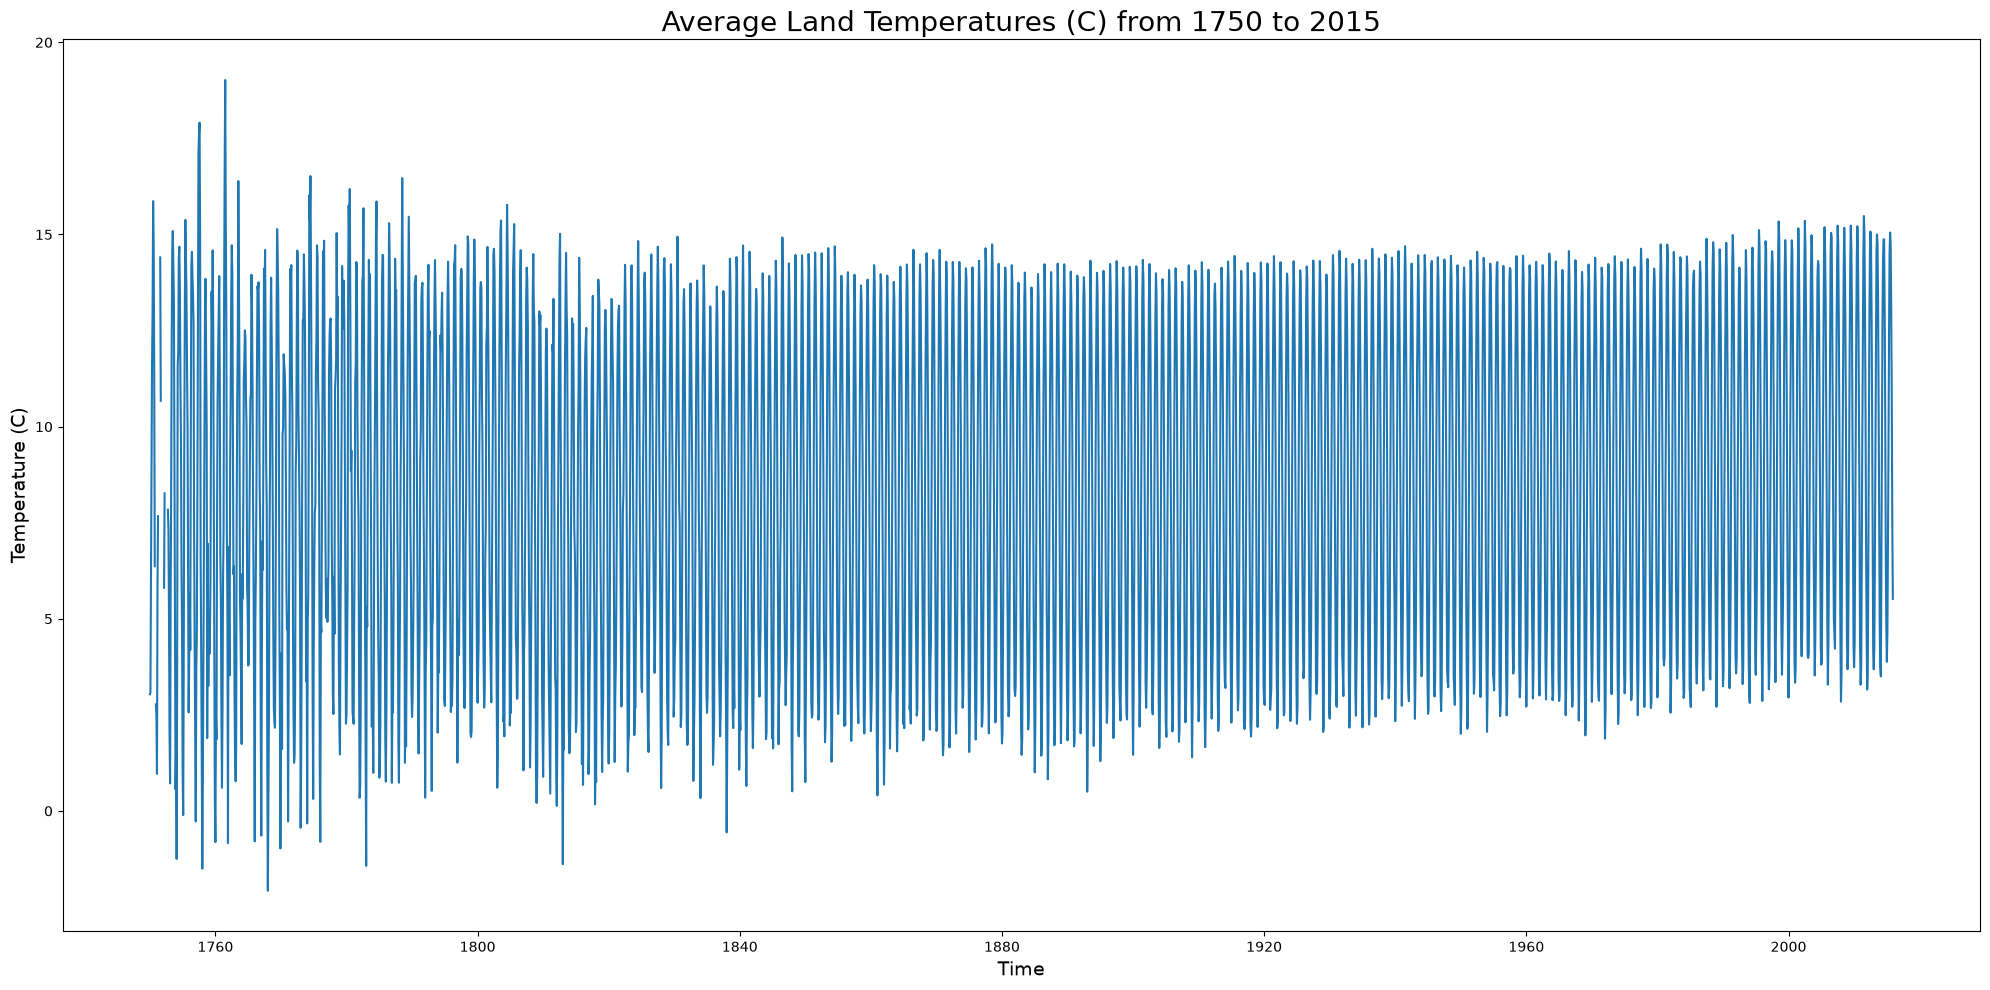

In [ ]:
first_year = df['dt'].dt.year.min()
last_year = df['dt'].dt.year.max()

plt.figure(figsize=(20, 10))
plt.plot(df['dt'], df['LandAverageTemperature'])
plt.xlabel('Time', fontsize=14)
plt.ylabel('Temperature (C)', fontsize=14)
plt.title(f'Average Land Temperatures (C) from {first_year} to {last_year}', fontsize=20)
plt.tight_layout()
plt.show()

### 3. Missing Data

In [21]:
df.isna().sum()

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
dtype: int64

### 4. Temperature Trends

### 5. Seasonality

In [36]:
df['month'] = df['dt'].dt.month
df.groupby('month')['LandAverageTemperature'].mean()

month
1      2.275211
2      2.961521
3      4.956872
4      8.248688
5     11.153053
6     13.343415
7     14.307784
8     13.760064
9     11.723170
10     8.884943
11     5.742405
12     3.198977
Name: LandAverageTemperature, dtype: float64

### 6. Uncertainty

### 7. Preliminary Findings